# Explore here

In [1]:
# Your code here
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
main_df = pd.read_csv("https://raw.githubusercontent.com/4GeeksAcademy/data-preprocessing-project-tutorial/main/AB_NYC_2019.csv")
main_df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [3]:
main_df.to_csv("../data/raw/total_data.csv", index = False)

### COMPLETE EDA

In [4]:
# Check for NA values 
main_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [5]:
main_df.nunique()

id                                48895
name                              47905
host_id                           37457
host_name                         11452
neighbourhood_group                   5
neighbourhood                       221
latitude                          19048
longitude                         14718
room_type                             3
price                               674
minimum_nights                      109
number_of_reviews                   394
last_review                        1764
reviews_per_month                   937
calculated_host_listings_count       47
availability_365                    366
dtype: int64

### Dropping Columns
a) The columns *last_review* and *reviews_per_month* are missing about 20% of their values. I am going to drop them and look at the more general *number_of reviews* column. Especially because I do not have any other time-based data to compare to, such as change in price over time or how old the listing is.

b) I am also going to drop *latitude*, *longitude*, and *neighbourhood*. Just using *neigbourhood_group* which gives 5 bucket categories for possible locations.

c) After checking for duplicates, I will eliminate the idientifiers that won't be used in prediction: *id*, *name*, *host_id*, and *host_name*.

d) I am also curious if the last two columns *calculated_host_listings_count* and *availability_365* will have much information, if not I will drop them.

In [6]:
# checking for duplicates in id column
main_df.drop("id", axis = 1).duplicated().sum()

np.int64(0)

No duplicates in the *id* column

<Axes: ylabel='calculated_host_listings_count'>

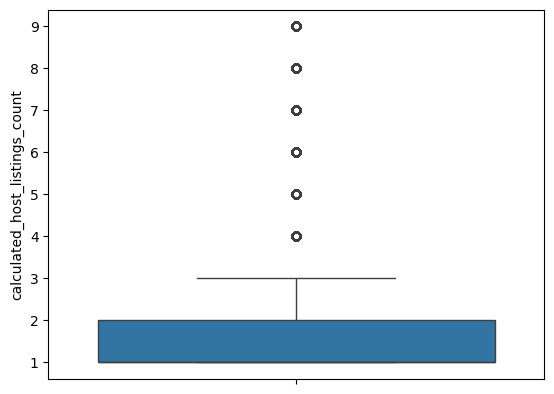

In [7]:
# investigating number of listings 
sns.boxplot(main_df['calculated_host_listings_count'][main_df['calculated_host_listings_count']<10])

In [8]:
main_df['calculated_host_listings_count'].value_counts()

calculated_host_listings_count
1      32303
2       6658
3       2853
4       1440
5        845
6        570
8        416
7        399
327      327
9        234
232      232
10       210
96       192
12       180
13       130
121      121
11       110
52       104
103      103
33        99
49        98
91        91
87        87
15        75
14        70
23        69
17        68
34        68
65        65
31        62
28        56
18        54
50        50
25        50
47        47
43        43
20        40
39        39
37        37
32        32
30        30
29        29
27        27
26        26
21        21
19        19
16        16
Name: count, dtype: int64

Most hosts appear to have 1 listing and few have more than 4, I could engineer the *calculated_host_listings_count* column into 2 or 3 buckets, but I am going to drop it because of the potential for redundant data. For example, if a host has four properties, all four of their properties will have 4 as the value in this column.

<Axes: ylabel='availability_365'>

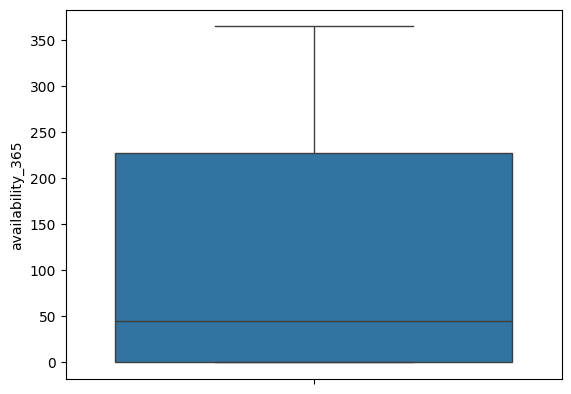

In [9]:
sns.boxplot(main_df['availability_365'])

In [10]:
main_df['availability_365'].value_counts()

availability_365
0      17533
365     1295
364      491
1        408
89       361
       ...  
195       26
183       24
196       24
181       23
202       20
Name: count, Length: 366, dtype: int64

The *availability_365* column seems to have many values of 0. This does not make sense and therefore I will drop this column. 

In [11]:
# dropping all found irrelevant columns
drop_list = ['id', 'name', 'host_id', 'host_name', 'neighbourhood', 'latitude', 'longitude', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']

In [12]:
main_df.drop(drop_list, axis = 1, inplace = True)
main_df.head()

,neighbourhood_group,room_type,price,minimum_nights,number_of_reviews
0,Brooklyn,Private room,149,1,9
1,Manhattan,Entire home/apt,225,1,45
2,Manhattan,Private room,150,3,0
3,Brooklyn,Entire home/apt,89,1,270
4,Manhattan,Entire home/apt,80,10,9


## Categorical Variables

<Axes: xlabel='room_type', ylabel='Count'>

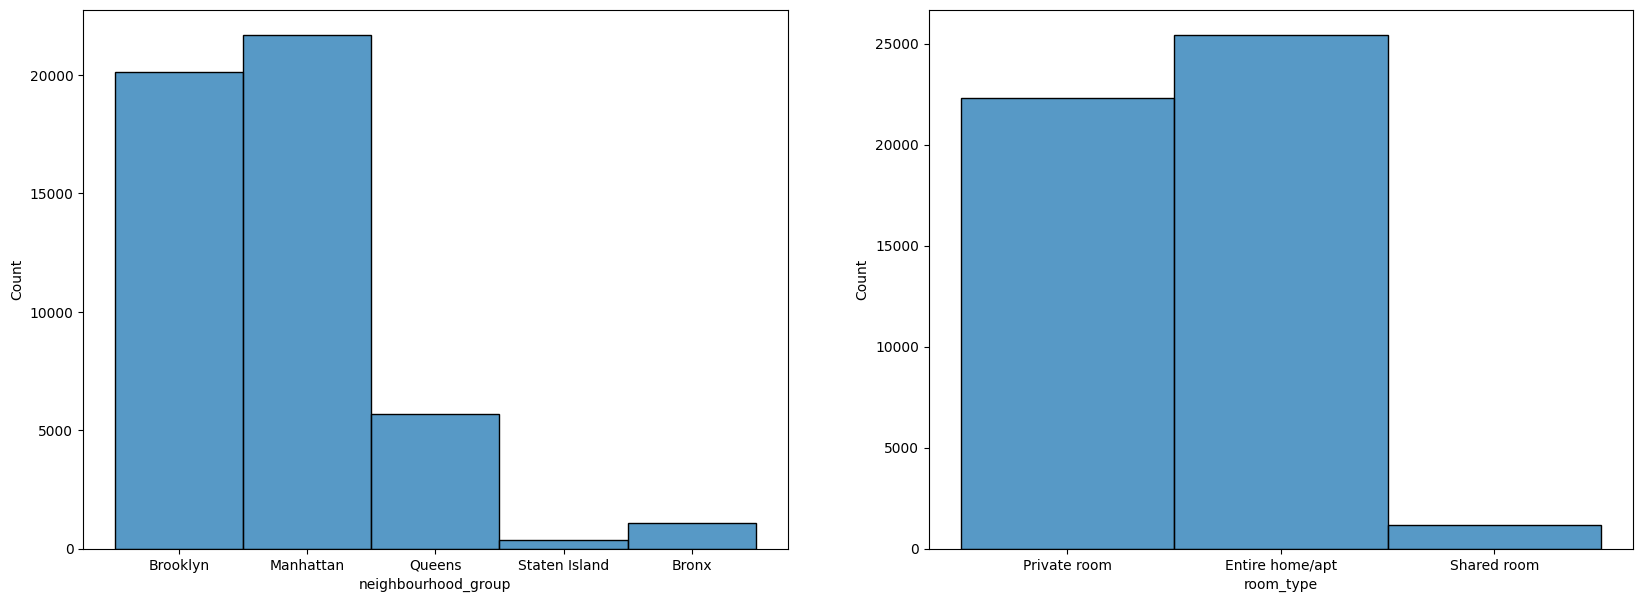

In [13]:
# I will plot the categorical variables neighbourhood_group and room_type on histograms 
fig, axis = plt.subplots(1, 2, figsize = (20, 7))

sns.histplot(ax = axis[0], data = main_df, x = "neighbourhood_group")
sns.histplot(ax = axis[1], data = main_df, x = "room_type")

More than 75% of listings are in Brooklyn or Manhattan.

Very few listings are for shared rooms.

## Numeric Variables

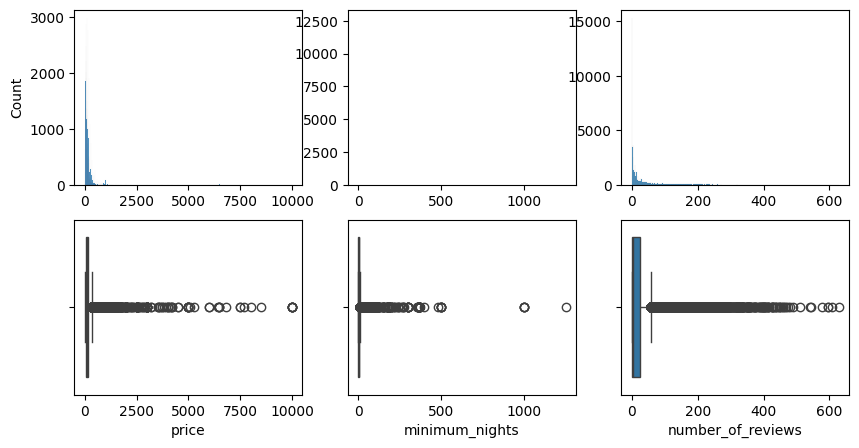

In [14]:
fig, axis = plt.subplots(2,3, figsize = (10,5))

sns.histplot(ax = axis[0, 0], data = main_df, x = "price").set(xlabel = None)
sns.boxplot(ax = axis[1, 0], data = main_df, x = "price")
sns.histplot(ax = axis[0, 1], data = main_df, x = "minimum_nights").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[1, 1], data = main_df, x = "minimum_nights")
sns.histplot(ax = axis[0, 2], data = main_df, x = "number_of_reviews").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[1, 2], data = main_df, x = "number_of_reviews")


plt.show()

Here we see all the numerical variables are skewed to the left and the higher values are outliers.

In [15]:
main_df.head(10)

,neighbourhood_group,room_type,price,minimum_nights,number_of_reviews
0,Brooklyn,Private room,149,1,9
1,Manhattan,Entire home/apt,225,1,45
2,Manhattan,Private room,150,3,0
3,Brooklyn,Entire home/apt,89,1,270
4,Manhattan,Entire home/apt,80,10,9
5,Manhattan,Entire home/apt,200,3,74
6,Brooklyn,Private room,60,45,49
7,Manhattan,Private room,79,2,430
8,Manhattan,Private room,79,2,118
9,Manhattan,Entire home/apt,150,1,160


## Observed data relationships
### Numerical variables

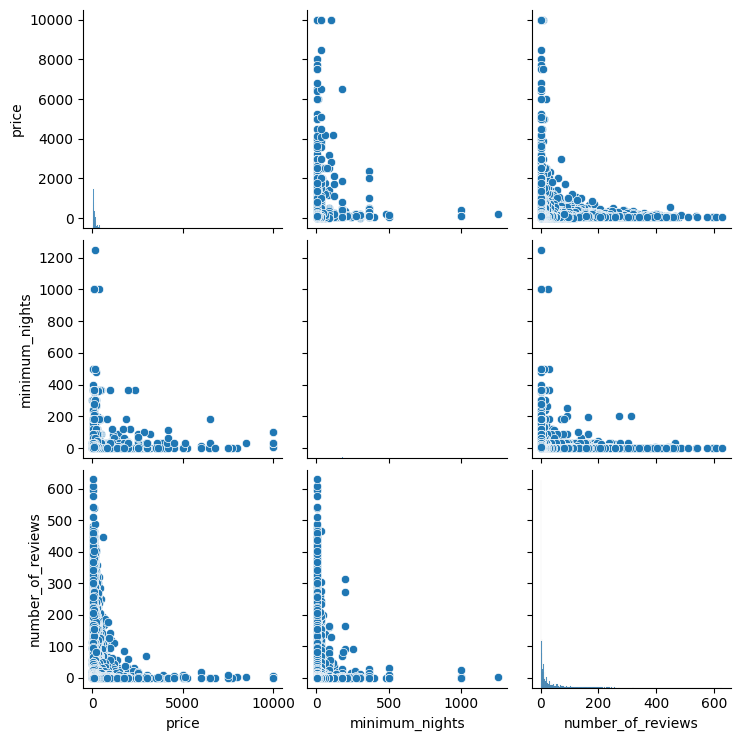

In [16]:
sns.pairplot(main_df)

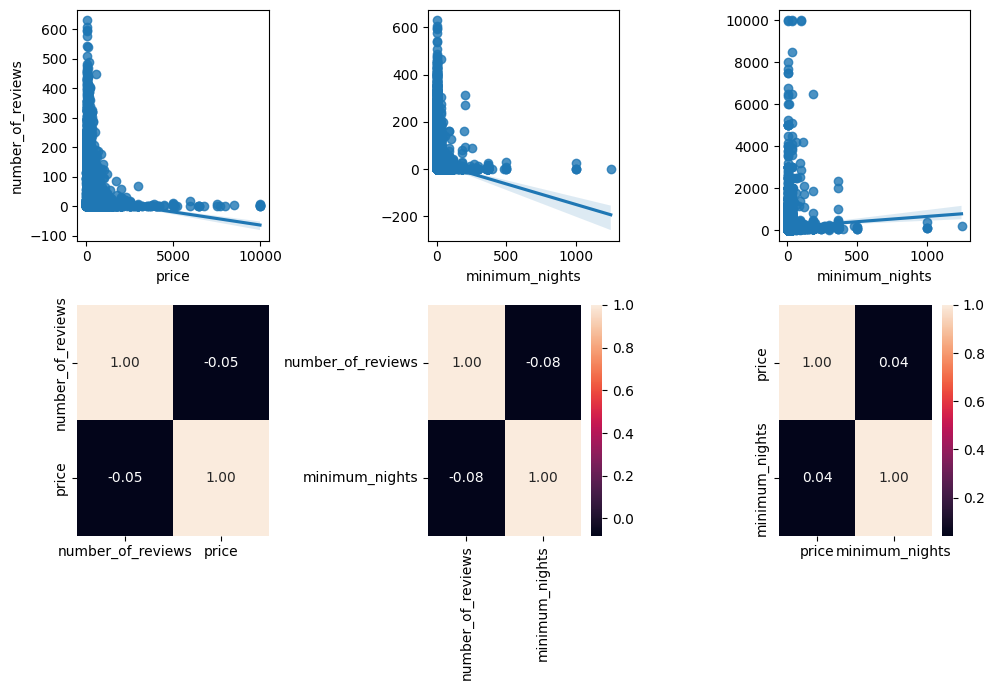

In [17]:
fig, axis = plt.subplots(2, 3, figsize = (10, 7))

# Create a multiple scatter diagram
sns.regplot(ax = axis[0, 0], data = main_df, x = "price", y = "number_of_reviews")
sns.heatmap(main_df[["number_of_reviews", "price"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 0], cbar = False)
sns.regplot(ax = axis[0, 1], data = main_df, x = "minimum_nights", y = "number_of_reviews").set(ylabel=None)
sns.heatmap(main_df[["number_of_reviews", "minimum_nights"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 1])
sns.regplot(ax = axis[0, 2], data = main_df, x = "minimum_nights", y = "price").set(ylabel=None)
sns.heatmap(main_df[["price", "minimum_nights"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 2])

# Adjust the layout
plt.tight_layout()

# Show the plot
plt.show()

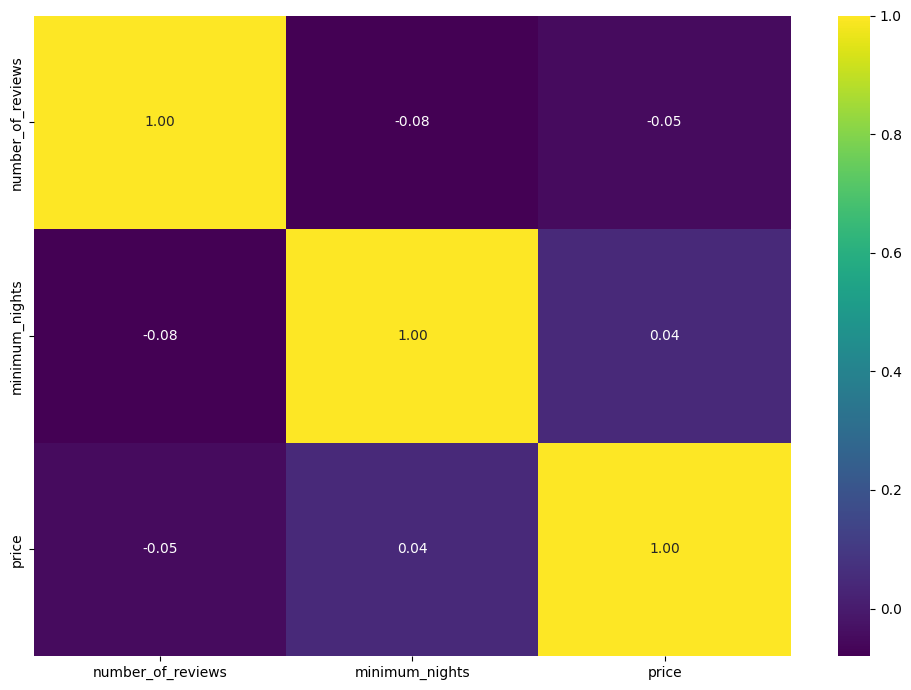

In [18]:
fig, ax = plt.subplots(figsize=(10,7))
sns.heatmap(main_df[["number_of_reviews", "minimum_nights", "price"]].corr(method="pearson"), annot=True, fmt=".2f", cmap="viridis", ax=ax)
plt.tight_layout()
plt.show()

No apparent correlation between the numerical variables.

### Categorical variables

Here I will say that the price is my target variable

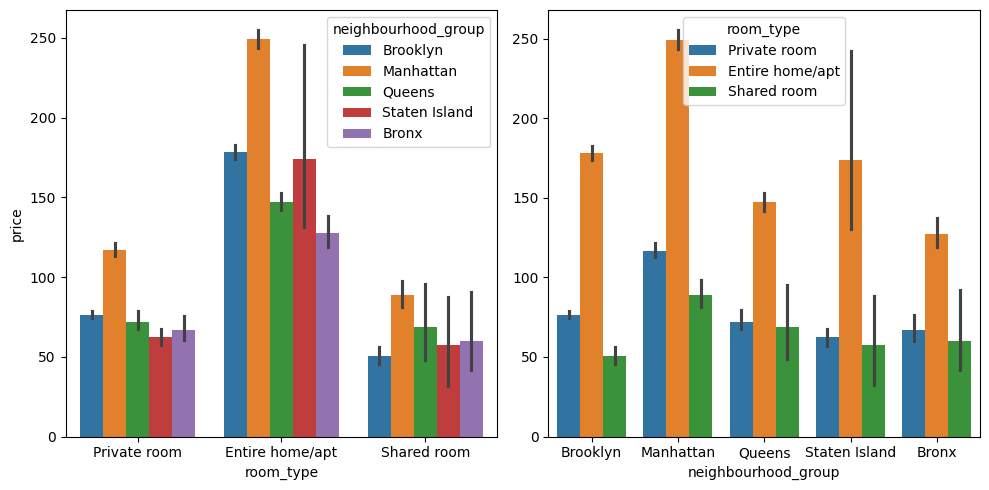

In [19]:
fig, axis = plt.subplots(figsize = (10, 5), ncols = 2)

sns.barplot(ax = axis[0], data = main_df, x = "room_type", y = "price", hue = "neighbourhood_group")
sns.barplot(ax = axis[1], data = main_df, x = "neighbourhood_group", y = "price", hue = "room_type").set(ylabel = None)

plt.tight_layout()

plt.show()

These graphs show the same thing. This shows an entire unit located in Manhattan has the highest average price while a shared room in Brooklyn has the lowest average price.
So price definitely has some relationship to location and unit type.

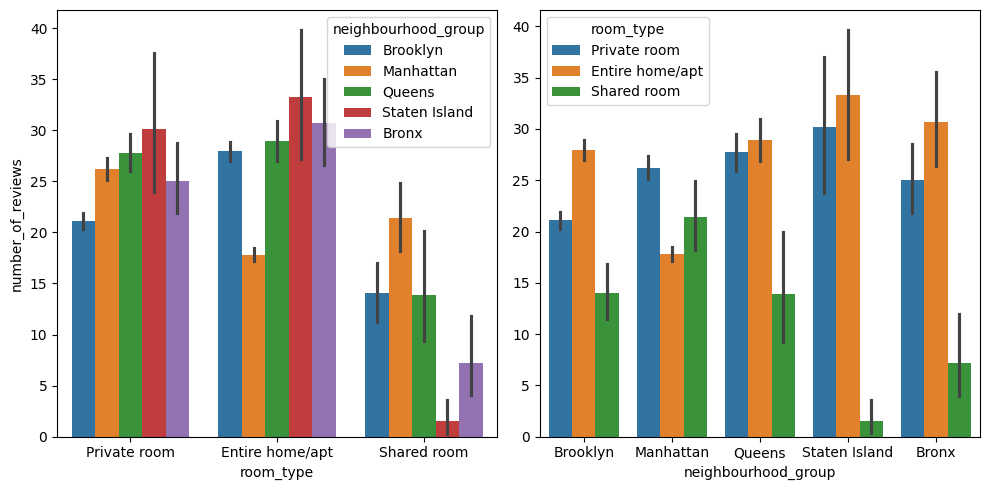

In [20]:
fig, axis = plt.subplots(figsize = (10, 5), ncols = 2)

sns.barplot(ax = axis[0], data = main_df, x = "room_type", y = "number_of_reviews", hue = "neighbourhood_group")
sns.barplot(ax = axis[1], data = main_df, x = "neighbourhood_group", y = "number_of_reviews", hue = "room_type").set(ylabel = None)

plt.tight_layout()


## Price by category

In [21]:
display(main_df.groupby("room_type")["price"].mean().rename("stay_rates").to_frame())
display(main_df.groupby("neighbourhood_group")["price"].mean().rename("stay_rates").to_frame())

,stay_rates
room_type,
Entire home/apt,211.794246
Private room,89.780973
Shared room,70.127586


,stay_rates
neighbourhood_group,
Bronx,87.496792
Brooklyn,124.383207
Manhattan,196.875814
Queens,99.517649
Staten Island,114.812332


Now I will look for outliers in my target variable (price)

In [22]:
main_df["price"].groupby(main_df["neighbourhood_group"]).describe()

,count,mean,std,min,25%,50%,75%,max
neighbourhood_group,,,,,,,,
Bronx,1091.0,87.496792,106.709349,0.0,45.0,65.0,99.0,2500.0
Brooklyn,20104.0,124.383207,186.873538,0.0,60.0,90.0,150.0,10000.0
Manhattan,21661.0,196.875814,291.383183,0.0,95.0,150.0,220.0,10000.0
Queens,5666.0,99.517649,167.102155,10.0,50.0,75.0,110.0,10000.0
Staten Island,373.0,114.812332,277.620403,13.0,50.0,75.0,110.0,5000.0


In [23]:
main_df["price"].groupby(main_df["room_type"]).describe()

,count,mean,std,min,25%,50%,75%,max
room_type,,,,,,,,
Entire home/apt,25409.0,211.794246,284.041611,0.0,120.0,160.0,229.0,10000.0
Private room,22326.0,89.780973,160.205262,0.0,50.0,70.0,95.0,10000.0
Shared room,1160.0,70.127586,101.725252,0.0,33.0,45.0,75.0,1800.0


Looking at the max and min value there are clearly outliers with very high prices and prices of 0.

While the price of zero is likely missing data, the very high price outliers are possibly real and reflect unseen information like unit size or other features.

In [24]:
#dropping values where price is zero

main_df = main_df[main_df["price"] != 0]

In [25]:
main_df["price"].describe()

count    48884.000000
mean       152.755053
std        240.170260
min         10.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64

Scaling the features

In [26]:
# Factorize the Room Type and Neighborhood Data
room_codes,room_unique = pd.factorize(main_df["room_type"], sort=True)
neighbourhood_codes,neighbourhood_unique = pd.factorize(main_df["neighbourhood_group"], sort=True)
main_df["room_type"] = room_codes
main_df["neighbourhood_group"] = neighbourhood_codes

/tmp/ipykernel_786/505655396.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  main_df["room_type"] = room_codes
/tmp/ipykernel_786/505655396.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  main_df["neighbourhood_group"] = neighbourhood_codes


In [27]:
from sklearn.preprocessing import MinMaxScaler

num_variables = ["number_of_reviews", "minimum_nights","neighbourhood_group", "room_type"]
scaler = MinMaxScaler()
scal_features = scaler.fit_transform(main_df[num_variables])
df_scal = pd.DataFrame(scal_features, index = main_df.index, columns = num_variables)
df_scal["price"] = main_df["price"]
df_scal.head()

,number_of_reviews,minimum_nights,neighbourhood_group,room_type,price
0,0.014308,0.000000,0.25,0.5,149
1,0.071542,0.000000,0.50,0.0,225
2,0.000000,0.001601,0.50,0.5,150
3,0.429253,0.000000,0.25,0.0,89
4,0.014308,0.007206,0.50,0.0,80


Feature Selection

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import chi2, SelectKBest

X = df_scal.drop("price", axis = 1)
y = df_scal["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y)

selection_model = SelectKBest(chi2, k = 4)
selection_model.fit(X_train, y_train)
ix = selection_model.get_support()
X_train_sel = pd.DataFrame(selection_model.transform(X_train), columns = X_train.columns.values[ix])
X_test_sel = pd.DataFrame(selection_model.transform(X_test), columns = X_test.columns.values[ix])

X_train_sel.head()

,number_of_reviews,minimum_nights,neighbourhood_group,room_type
0,0.027027,0.010408,0.50,0.0
1,0.000000,0.010408,0.25,0.5
2,0.009539,0.023219,0.50,0.0
3,0.004769,0.003203,0.25,0.5
4,0.357711,0.000801,0.25,0.0


In [29]:
X_train_sel["price"] = list(y_train)
X_test_sel["price"] = list(y_test)
X_train_sel.to_csv("../data/processed/clean_train.csv", index = False)
X_test_sel.to_csv("../data/processed/clean_test.csv", index = False)